# fucking around with decomposing l05 into large & small scales


In [1]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood
from DAPyr.MODELS import deconstruct_Z

reload(dap)

np.set_printoptions(suppress=True)


In [2]:
uoep = {'mu': 0, 'sigma': 2} 
poep = {'mu': 0, 'sigma': 2} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [3]:
e_name = 'L96: sdg'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 1,
                       'model_flag':2,
                       'localize':1,
                       'obf': 2,
                       'seed': 58,
                       'qc_flag': 0,
                       'h_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'force_hx_identity': False,
                       'Ne':80,
                       'T': 201,
                       'T_train': 400,
                       'train_frac': 1.0,
                       'nle_type': 5,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})



starting experiment L96: sdg


In [11]:
ens1 = e_sd_kecd.getStates()[0][:,0]
X, Y = deconstruct_Z(ens1)

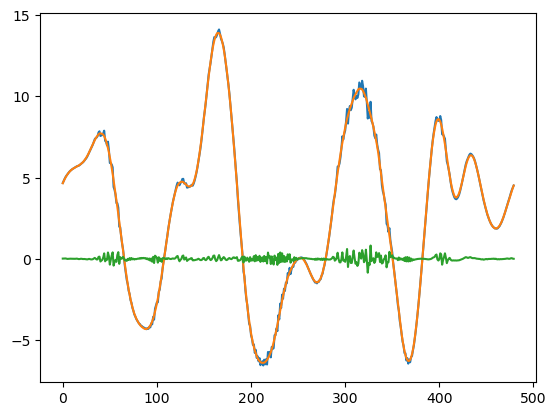

In [12]:
plt.plot(ens1)
plt.plot(X)
plt.plot(Y)


In [ ]:
def h_weighted(Y, hw=3):
    